In [ ]:
import marimo as mo

#Улучшение качества модели
Для анализа полярности фрагментов текста CatBoost имеет ряд преимуществ:
- может работать с категориальными признаками, в том числе и с текстом, из коробки
- симметричные деревья — меньше переобучаются на шумных текстовых данных
- скорость инференса — важна, если будете применять модель к новым твитам

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [ ]:
data=pd.read_csv('data\processed\clean_data.csv', delimiter=',')
data = data.dropna(subset=['text']) #на этапе EDA мы подготавливали 
X=data.drop(columns=['y'])
y=data['y']

In [ ]:
#Базовый catboost
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=17,
    stratify=y
)

train_pool = Pool(
    X_train,
    y_train,
    cat_features=['day', 'time'],
    text_features=['text']
)

test_pool = Pool(
    X_test,
    y_test,
    cat_features=['day', 'time'],
    text_features=['text']
)

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,

    loss_function='Logloss',

    task_type="GPU",
    devices="0",

    verbose=100
)

model.fit(train_pool, eval_set=test_pool)

0:	learn: 0.6501521	test: 0.6492117	best: 0.6492117 (0)	total: 201ms	remaining: 1m 40s
100:	learn: 0.4416219	test: 0.4377889	best: 0.4377889 (100)	total: 4.8s	remaining: 19s
200:	learn: 0.4331026	test: 0.4299558	best: 0.4299558 (200)	total: 9.11s	remaining: 13.6s
300:	learn: 0.4279351	test: 0.4253561	best: 0.4253561 (300)	total: 13.3s	remaining: 8.78s
400:	learn: 0.4242193	test: 0.4221396	best: 0.4221396 (400)	total: 17.3s	remaining: 4.27s
499:	learn: 0.4210610	test: 0.4195010	best: 0.4195010 (499)	total: 21.2s	remaining: 0us
bestTest = 0.4195009752
bestIteration = 499


<catboost.core.CatBoostClassifier object at 0x00000184AE018820>

In [ ]:
y_train_prediction_cb=model.predict(X_train)
y_train_prediction_prob_cb=model.predict_proba(X_train)[:,1]
y_test_prediction_cb=model.predict(X_test)
y_test_prediction_prob_cb=model.predict_proba(X_test)[:,1]
df=pd.DataFrame(
    {"Какая выборка?": ["Train","Test"],
     "Accuracy метрика": [accuracy_score(y_train, y_train_prediction_cb),accuracy_score(y_test,y_test_prediction_cb)],
     "F1-мера": [f1_score(y_train, y_train_prediction_cb),f1_score(y_test,y_test_prediction_cb)]
        }
)
print(df)

  Какая выборка?  Accuracy метрика   F1-мера
0          Train          0.817739  0.817270
1           Test          0.809539  0.809169


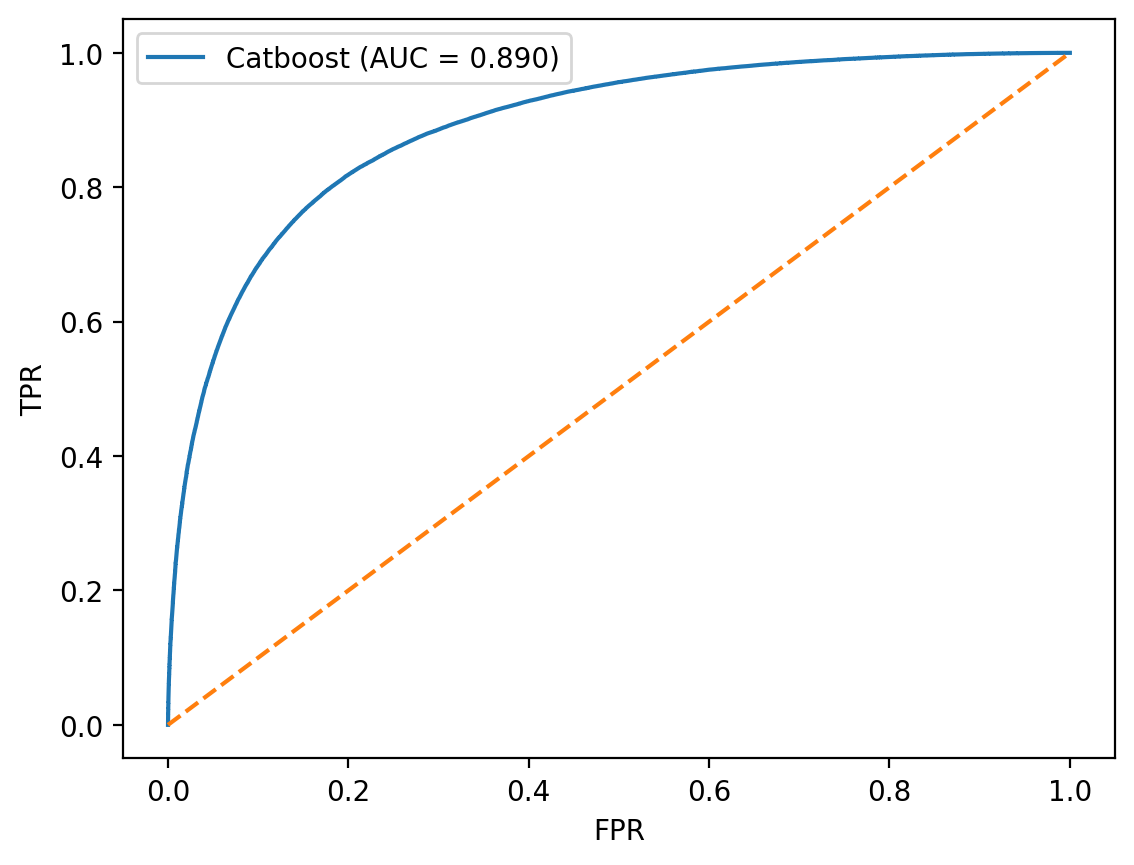

In [ ]:
#ROC-AUC
fpr_cb, tpr_cb, _ = roc_curve(y_test, y_test_prediction_prob_cb) #false positive rate (доля ложноположительных срабатываний), true positive rate (чувствительность recall)
roc_auc_cb = auc(fpr_cb, tpr_cb) #AUC = 1 — идеальная классификация, 0.5 — случайная

plt.plot(fpr_cb, tpr_cb, label=f'Catboost (AUC = {roc_auc_cb:.3f})')

plt.plot([0,1],[0,1],'--') ## Эта линия соответствует случайной модели (AUC=0.5)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.savefig('image/catboost_roc_curve.png')
plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_test_prediction_cb) #матрица неточностей, показывающая TP, FN, TN, FP
cm_df = pd.DataFrame(
    cm,
    index=['Negative', 'Positive'],
    columns=['Predicted Negative', 'Predicted Positive']
)

print(cm_df)
print(f"Precission for train: {precision_score(y_train, y_train_prediction_cb):.3f}\nRecall for train: {recall_score(y_train, y_train_prediction_cb):.3f}\nPrecission for test: {precision_score(y_test, y_test_prediction_cb):.3f}\nRecall for test: {recall_score(y_test, y_test_prediction_cb):.3f}")

          Predicted Negative  Predicted Positive
Negative              129548               30121
Positive               30691              128929
Precission for train: 0.819
Recall for train: 0.815
Precission for test: 0.811
Recall for test: 0.808


In [ ]:
#catboost напрямую не дает посмотреть важность слов, но дает оценить важность стобцов
fi = model.get_feature_importance(prettified=True)
print(fi.head(10))

  Feature Id  Importances
0       text    82.673500
1        day    12.417763
2       time     4.908737


#Итог
Итогом стала модель catboost

##Результаты
|Метрика|Train|Test|
|:-----:|:----:|:--:|
|Accuracy|0.817690|0.817252|
|F1-мера|0.809373|0.809117|
|Recall|0.815|0.808|
|Precission|0.819|0.810|

##Матрица неточностей
||Прогноз y>0|Прогноз y<0|
|:-----:|:----:|:--:|
|Реал y>0|128998|30622|
|Реал y<0|30243|129426|

, где TP = 128998, TN = 129426, FP = 30243, FN = 30622

##Следующий шаг - улучшение модели, путем настройки гиперпараметров модели